In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, RANSACRegressor

In [86]:
THRESHOLD_COOLING = 100   # Base cooling threshold [W]
THRESHOLD_HEATING = 50  # Base heating threshold [W]

YEAR = 2025
START = f"{YEAR}-01-01T00:00:00Z"
END = f"{YEAR + 1}-01-01T00:00:00Z"

SECONDS_PER_INTERVAL = {
    '1h': 3600,
    '6h': 6 * 3600,
    '1d': 86400,
    '7d': 7 * 86400,
    '30d': 30 * 86400
}

In [87]:
# Configuration for the new Influx-exported CSVs
DATA_FOLDER = 'files_from_influx_EnergySign'

# CSV file paths (raw long format: measurement,time,variable,value)
ENERGY_FILE = f'{DATA_FOLDER}/energy.csv'
TEMPERATURE_FILE = f'{DATA_FOLDER}/temperatures.csv'
DNI_FILE = f'{DATA_FOLDER}/dni.csv'

# Optional signals (not present in the new export)
SHADING_FILE = None

# Energy conversion factors (used only if you need PE post-processing)
PE_GAS = 1.00       # Primary energy factor for gas
PE_ELEC = 2.17      # Primary energy factor for electricity
COP_H = 0.98        # Coefficient of Performance for heating
EER_C = 5.4         # Energy Efficiency Ratio for cooling

In [88]:
def _load_influx_long_csv(file_path, file_tag):
    """
    Load a CSV exported from InfluxDB in long format
    (measurement, time, variable, value) and return a wide DataFrame indexed by time.
    """
    df = pd.read_csv(file_path)

    # Normalize first 4 columns if needed
    expected = ['measurement', 'time', 'variable', 'value']
    if not set(expected).issubset(df.columns):
        if df.shape[1] >= 4:
            df = df.iloc[:, :4].copy()
            df.columns = expected
        else:
            raise ValueError(f"{file_tag}: unexpected CSV format in {file_path}")

    # Parse timestamp (Influx export can be ns epoch or ISO string)
    if pd.api.types.is_numeric_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'], unit='ns', errors='coerce')
    else:
        df['time'] = pd.to_datetime(df['time'], errors='coerce')

    # Keep valid rows only
    df = df.dropna(subset=['time', 'variable', 'value'])

    # Pivot to wide format
    wide = df.pivot_table(index='time', columns='variable', values='value', aggfunc='mean')
    wide = wide.sort_index()

    return wide


def load_from_csv(energy_file, temperature_file, dni_file=None):
    """
    Load and merge data from Influx-exported CSV files.
    Returns a cleaned DataFrame ready for energy-signature analysis.
    """
    print("Loading CSV files...")

    df_temp = _load_influx_long_csv(temperature_file, 'temperature')
    df_energy = _load_influx_long_csv(energy_file, 'energy')

    # Same merge logic as k-signature: temp + energy inner join
    dataset = df_temp.join(df_energy, how='inner')

    # DNI optional
    if dni_file:
        df_dni = _load_influx_long_csv(dni_file, 'dni')
        dataset = dataset.join(df_dni, how='left')

    # Identify raw energy columns before renaming
    raw_energy_cols = [
        c for c in dataset.columns
        if ('DistrictHeating' in c) or ('DistrictCooling' in c) or (c == 'Electricity') or ('Electricity' in c)
    ]
    raw_aux_cols = [c for c in dataset.columns if c not in raw_energy_cols]

    # Clean and align
    dataset = dataset.sort_index()

    # Fill only auxiliary signals (temperature/weather), NOT energy
    if raw_aux_cols:
        dataset[raw_aux_cols] = dataset[raw_aux_cols].ffill()

    # For energy columns, missing values are interpreted as zero load at that timestep
    if raw_energy_cols:
        dataset[raw_energy_cols] = dataset[raw_energy_cols].fillna(0.0)

    # Keep rows where at least one energy signal exists
    if raw_energy_cols:
        dataset = dataset[(dataset[raw_energy_cols].abs().sum(axis=1) >= 0)]

    # Bring time back as a column
    dataset = dataset.reset_index().rename(columns={'index': 'time'})

    # Standardize column names
    column_mapping = {}
    for col in dataset.columns:
        if col == 'time':
            continue
        if 'DistrictCooling' in col:
            column_mapping[col] = 'DistrictCooling'
        elif 'DistrictHeating' in col:
            column_mapping[col] = 'DistrictHeating'
        elif 'Electricity' in col and 'DistrictCooling' not in col and 'DistrictHeating' not in col:
            column_mapping[col] = 'Electricity'
        elif 'Tin_Flat2_Zona1' in col or ('Zona1' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z1'
        elif 'Tin_Flat2_Zona2' in col or ('Zona2' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z2'
        elif 'Tin_Flat2_Zona3' in col or ('Zona3' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z3'
        elif 'Tin_Flat2_Zona4' in col or ('Zona4' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z4'
        elif col == 'Tout' or 'Tout' in col:
            column_mapping[col] = 'T_ext'
        elif 'DNI' in col:
            column_mapping[col] = 'DNI'

    dataset = dataset.rename(columns=column_mapping)

    # Remove duplicated columns produced by mapping collisions
    dataset = dataset.loc[:, ~dataset.columns.duplicated()]

    print(f"Loaded {len(dataset)} records")
    if not dataset.empty:
        print(f"Date range: {dataset['time'].min()} to {dataset['time'].max()}")
    print(f"Columns: {list(dataset.columns)}")

    dataset.to_csv('Energy_Signature_dataset.csv', index=False)
    return dataset

Preparing data with interval: 1h
Loading CSV files...
Loaded 19551 records
Date range: 2026-01-04 00:00:00 to 2027-01-01 00:00:00
Columns: ['time', 'Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4', 'T_ext', 'DistrictCooling', 'DistrictHeating', 'Electricity', 'DNI']
Detected native timestep ≈ 10.0 min
Winter season points: 3389
Winter points after filtering with threshold (50.00 W): 2054
Summer season points: 827
Summer points after filtering with threshold (100.00 W): 333


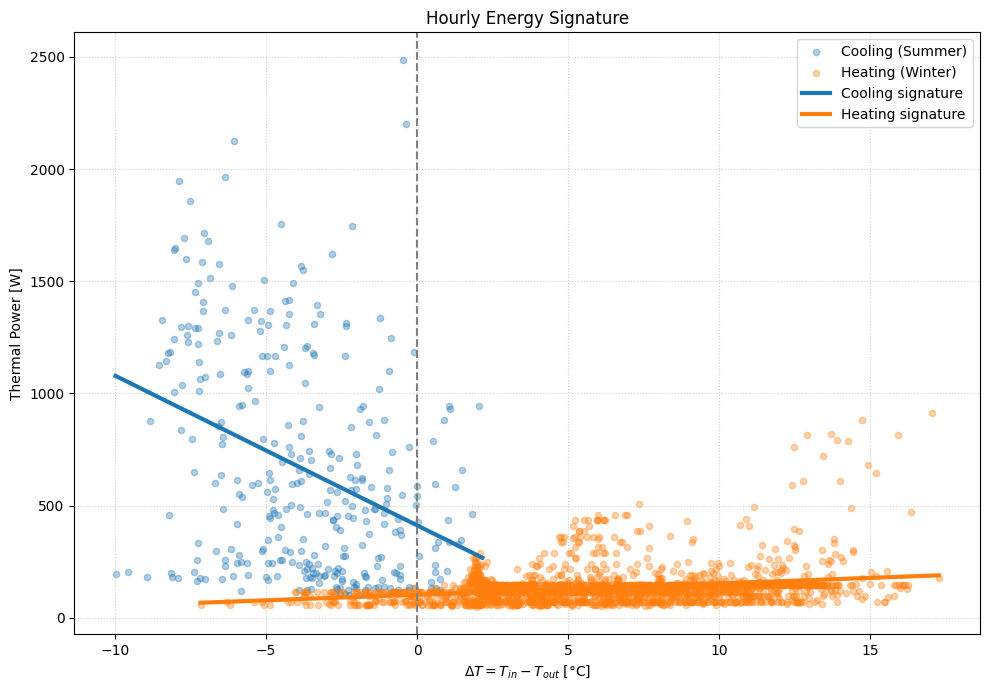

{'k_heating': np.float64(5.00266021305488), 'r2_heating': 0.0662017136219537, 'k_cooling': np.float64(-66.76080529194097), 'r2_cooling': 0.12790225323457616}
Preparing data with interval: 1d
Loading CSV files...
Loaded 19551 records
Date range: 2026-01-04 00:00:00 to 2027-01-01 00:00:00
Columns: ['time', 'Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4', 'T_ext', 'DistrictCooling', 'DistrictHeating', 'Electricity', 'DNI']
Detected native timestep ≈ 10.0 min
Winter season points: 167
Winter points after filtering with threshold (50.00 W): 129
Summer season points: 60
Summer points after filtering with threshold (100.00 W): 31


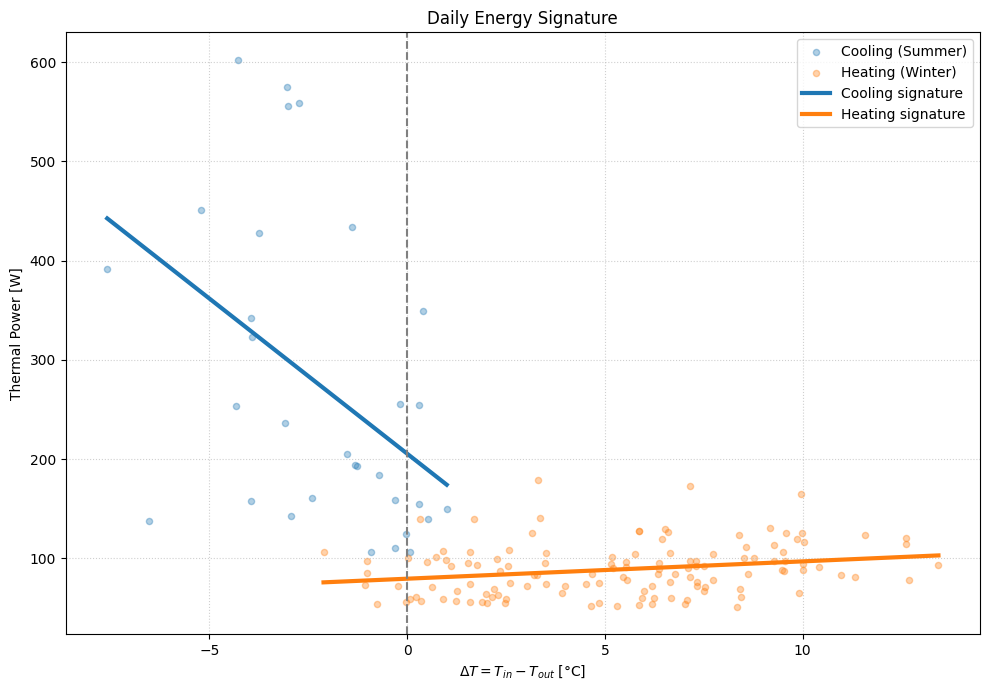

{'k_heating': np.float64(1.7461259711464319), 'r2_heating': 0.056503007395799165, 'k_cooling': np.float64(-31.26444906574451), 'r2_cooling': 0.1958521367442564}
Preparing data with interval: 7d
Loading CSV files...
Loaded 19551 records
Date range: 2026-01-04 00:00:00 to 2027-01-01 00:00:00
Columns: ['time', 'Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4', 'T_ext', 'DistrictCooling', 'DistrictHeating', 'Electricity', 'DNI']
Detected native timestep ≈ 10.0 min
Winter season points: 32
Winter points after filtering with threshold (50.00 W): 22
Summer season points: 16
Summer points after filtering with threshold (100.00 W): 4


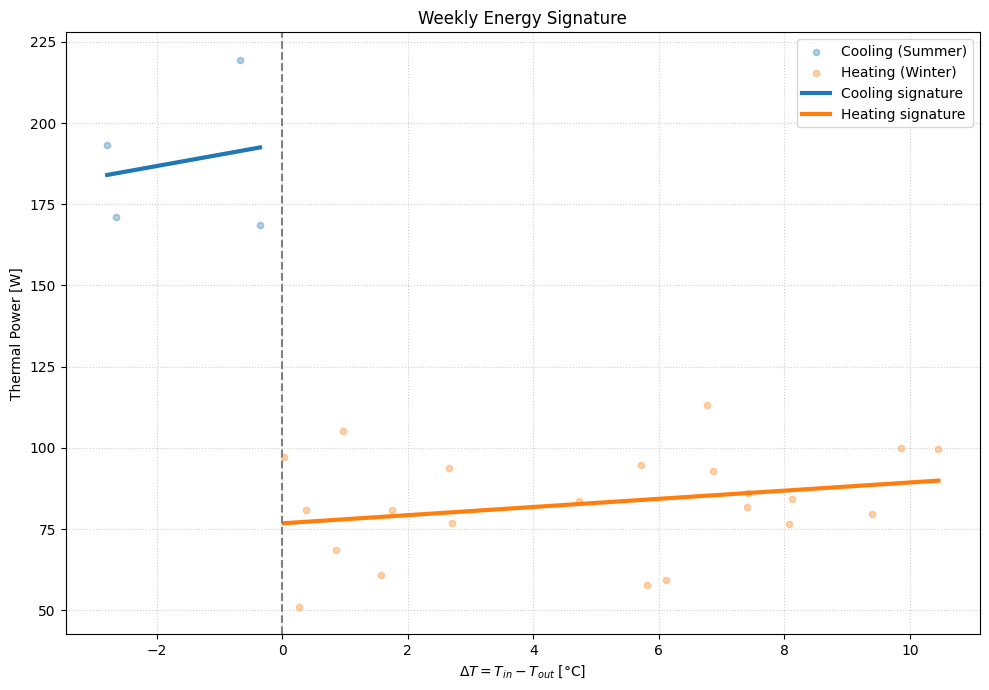

{'k_heating': np.float64(1.2579043363981868), 'r2_heating': 0.07054912032732386, 'k_cooling': np.float64(3.476545164637892), 'r2_cooling': 0.03542979141979352}
Preparing data with interval: 30d
Loading CSV files...
Loaded 19551 records
Date range: 2026-01-04 00:00:00 to 2027-01-01 00:00:00
Columns: ['time', 'Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4', 'T_ext', 'DistrictCooling', 'DistrictHeating', 'Electricity', 'DNI']
Detected native timestep ≈ 10.0 min
Winter season points: 9
Winter points after filtering with threshold (0.00 W): 9
Summer season points: 4
Summer points after filtering with threshold (0.00 W): 4


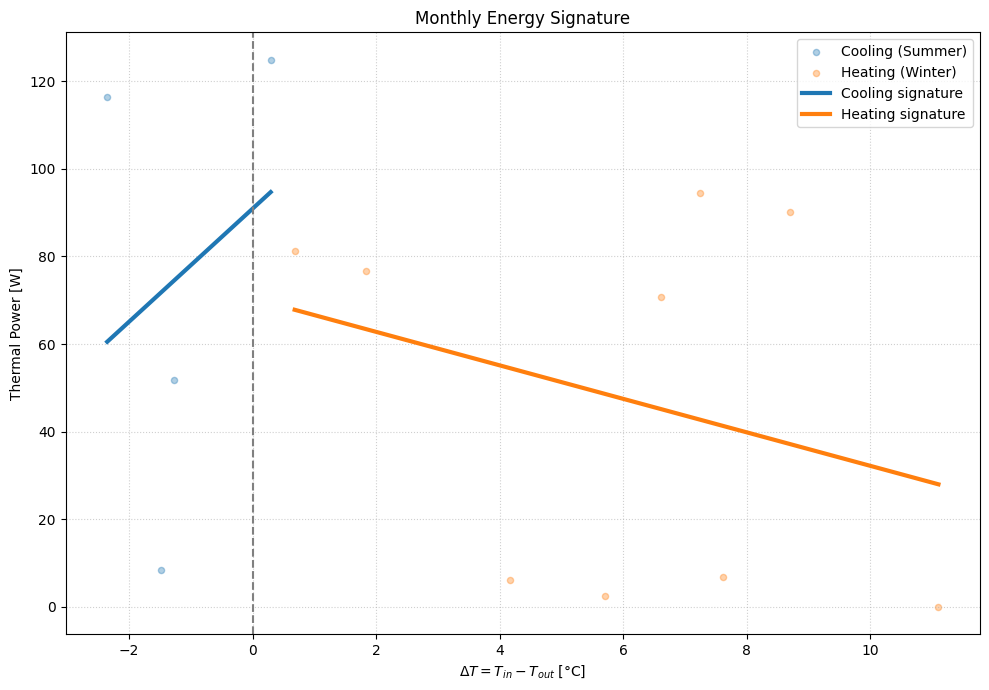

{'k_heating': np.float64(-3.823231523298261), 'r2_heating': 0.08964647764284683, 'k_cooling': np.float64(12.9083886619842), 'r2_cooling': 0.06621096256192305}


In [ ]:
def plot_energy_signature(group_by_time, title, threshold_cooling, threshold_heating):
    """
    Plot cooling/heating energy signatures for a chosen aggregation interval.
    """
    print(f"Preparing data with interval: {group_by_time}")
    dataset = load_from_csv(ENERGY_FILE, TEMPERATURE_FILE, DNI_FILE)

    if dataset.empty:
        print("No data available.")
        return

    dataset['time'] = pd.to_datetime(dataset['time'])
    dataset = dataset.sort_values('time').set_index('time')

    # Check native data resolution (no hardcoded 6h assumption)
    dt = dataset.index.to_series().diff().dropna()
    if not dt.empty:
        native_seconds = dt.median().total_seconds()
        print(f"Detected native timestep ≈ {native_seconds/60:.1f} min")

    # Ensure required signals exist
    required = ['DistrictHeating', 'DistrictCooling', 'T_ext']
    missing = [c for c in required if c not in dataset.columns]
    if missing:
        print(f"Missing required columns after mapping: {missing}")
        return

    # Indoor mean temperature
    t_zones = [c for c in ['Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4'] if c in dataset.columns]
    if not t_zones:
        print("No indoor zone temperature columns found (expected Tair_z1..Tair_z4).")
        return

    # Aggregation
    agg_dict = {}
    for col in dataset.columns:
        if col in ['DistrictHeating', 'DistrictCooling', 'Electricity']:
            agg_dict[col] = 'sum'
        else:
            agg_dict[col] = 'mean'

    df = dataset.resample(group_by_time).agg(agg_dict).reset_index()
    if df.empty:
        print("No data after aggregation.")
        return

    # Build Delta_T after aggregation
    t_zones_in_df = [c for c in t_zones if c in df.columns]
    if not t_zones_in_df:
        print("No indoor zone temperature columns available after aggregation.")
        return

    df['T_in_avg'] = df[t_zones_in_df].mean(axis=1)
    df['Delta_T'] = df['T_in_avg'] - df['T_ext']

    # Convert to thermal power
    dt_seconds = pd.to_timedelta(group_by_time).total_seconds()
    df['QH'] = df['DistrictHeating'].abs() / dt_seconds # QH represents thermal power used for heating
    df['QC'] = df['DistrictCooling'].abs() / dt_seconds # QC represents thermal power used for cooling
    
    # Keep only valid rows
    df = df.dropna(subset=['time', 'Delta_T', 'QH', 'QC'])
    if df.empty:
        print("No valid rows after cleaning.")
        return

    month = df['time'].dt.month
    is_cooling_season = month.isin([6, 7, 8, 9])  # June, July, August, September

    df_winter = df[~is_cooling_season].copy()
    print(f"Winter season points: {len(df_winter)}")

    thr = threshold_heating if group_by_time != '30d' else 0.0

    df_winter = df_winter[(df_winter['QH'] > thr)].copy()
    print(f"Winter points after filtering with threshold ({thr:.2f} W): {len(df_winter)}")

    df_summer = df[is_cooling_season].copy()
    print(f"Summer season points: {len(df_summer)}")

    thr = threshold_cooling if group_by_time != '30d' else 0.0

    df_summer = df_summer[(df_summer['QC'] > thr)].copy()
    print(f"Summer points after filtering with threshold ({thr:.2f} W): {len(df_summer)}")

    stats = {
        'k_heating': None, 'r2_heating': None,
        'k_cooling': None, 'r2_cooling': None
    }

    plt.figure(figsize=(10, 7))

    # cooling signature: Delta_T vs Qc (summer)
    if not df_summer.empty:
        plt.scatter(
            df_summer['Delta_T'],
            df_summer['QC'],
            label='Cooling (Summer)',
            color='tab:blue',
            alpha=0.35,
            s=20
        )

    # heating signature: Delta_T vs QH (winter)
    if not df_winter.empty:
        plt.scatter(
            df_winter['Delta_T'],
            df_winter['QH'],
            label='Heating (Winter)',
            color='tab:orange',
            alpha=0.35,
            s=20
        )

    if len(df_summer) >= 2:
        z_c = np.polyfit(df_summer['Delta_T'], df_summer['QC'], 1)
        p_c = np.poly1d(z_c)
        x = np.sort(df_summer['Delta_T'])
        plt.plot(x, p_c(x), linewidth=3, label='Cooling signature', color='tab:blue')

        stats['k_cooling'] = z_c[0]
        stats['r2_cooling'] = r2_score(df_summer['QC'], p_c(df_summer['Delta_T']))

    if len(df_winter) >= 2:
        z_h = np.polyfit(df_winter['Delta_T'], df_winter['QH'], 1)
        p_h = np.poly1d(z_h)
        x = np.sort(df_winter['Delta_T'])
        plt.plot(x, p_h(x), linewidth=3, label='Heating signature', color='tab:orange')

        stats['k_heating'] = z_h[0]
        stats['r2_heating'] = r2_score(df_winter['QH'], p_h(df_winter['Delta_T']))

    plt.title(title)
    plt.xlabel(r'$\Delta T = T_{in} - T_{out}$ [°C]')
    plt.ylabel('Thermal Power [W]')
    plt.axvline(x=0, color='gray', linestyle='--')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(stats)


# Plot the hourly energy signature
group_time_hour = '1h'
title_hour = 'Hourly Energy Signature'
plot_energy_signature(group_time_hour, title_hour, THRESHOLD_COOLING, THRESHOLD_HEATING)

# Plot the daily energy signature
group_time_day = '1d'
title_day = 'Daily Energy Signature'
plot_energy_signature(group_time_day, title_day, THRESHOLD_COOLING, THRESHOLD_HEATING)

# Plot the weekly energy signature
group_time_week = '7d'
title_week = 'Weekly Energy Signature'
plot_energy_signature(group_time_week, title_week, THRESHOLD_COOLING, THRESHOLD_HEATING)

# Plot the monthly energy signature
group_time_month = '30d'
title_month = 'Monthly Energy Signature'
plot_energy_signature(group_time_month, title_month, THRESHOLD_COOLING, THRESHOLD_HEATING)